In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB,BernoulliNB

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    f1_score,
    recall_score
    )


In [28]:
train_data=fetch_20newsgroups(
    subset="train",
    remove=("header","footer","quotes")
)

In [29]:
test_data=fetch_20newsgroups(
    subset="test",
    remove=("header","footer","qoutes")
)

In [38]:
x_train_text=train_data.data
y_train=train_data.target

x_test_text=test_data.data
y_test=test_data.target

class_names=train_data.target_names

In [31]:
print("training documents :",len(x_train_text))
print("testing document :",len(x_test_text))
print("number of classes :",len(class_names))

training documents : 11314
testing document : 7532
number of classes : 20


In [32]:
vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2
)

x_train =vectorizer.fit_transform(x_train_text)
x_test =vectorizer.transform(x_test_text)

In [33]:
print("Training feature matrix : ",x_train.shape)
print("Testing feature matrix : ",x_test.shape)

Training feature matrix :  (11314, 47541)
Testing feature matrix :  (7532, 47541)


In [34]:
mnb =MultinomialNB()
mnb.fit(
    x_train,
    y_train
)
y_pred_mnb=mnb.predict(x_test)

In [35]:
binary_vectorizer=CountVectorizer(
    stop_words="english",
    min_df=2,
    binary=True
)

x_train_binary=binary_vectorizer.fit_transform(
    x_train_text
)

x_test_binary=binary_vectorizer.transform(
    x_test_text
)



In [36]:
bnb=BernoulliNB()
bnb.fit(
    x_train_binary,
    y_train
)
y_pred_bnb =bnb.predict(
    x_test_binary
)


In [47]:
results = pd.DataFrame({
    "Model":[
        "Multinomial NB",
        "Bernoulli NB"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred_mnb),
        accuracy_score(y_test,y_pred_bnb),
    ],
    "Precision":[
        precision_score(
            y_test,
            y_pred_mnb,
            average="macro"
        ),
        precision_score(
            y_test,
            y_pred_bnb,
            average="macro"
        )
    ],
    "Recall":[
        recall_score(
            y_test,
            y_pred_mnb,
            average="macro"
        ),
        recall_score(
            y_test,
            y_pred_bnb,
            average="macro"
        )
    ],
      "F1-Score":[
          f1_score(
              y_test,
              y_pred_mnb,
              average="macro"
          ),
          f1_score(
              y_test,
              y_pred_bnb,
              average="macro"
          )
      ]
})
results
        

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial NB,0.796336,0.776344,0.788303,0.771352
1,Bernoulli NB,0.711232,0.769306,0.696998,0.683563


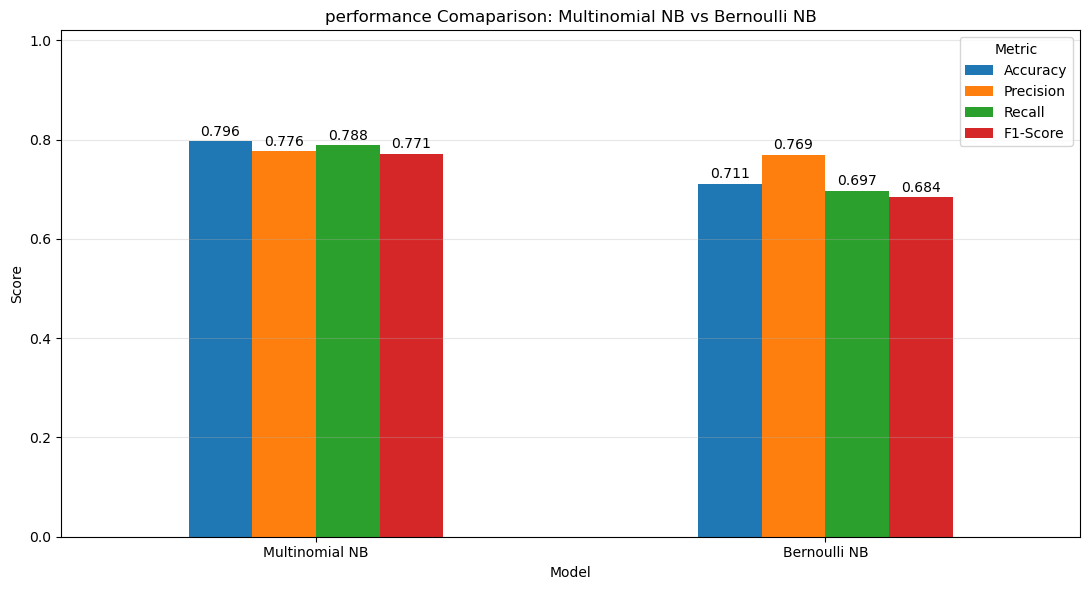

In [51]:
results_metrics=results[
    ["Model","Accuracy","Precision","Recall","F1-Score"]]
ax=results_metrics.set_index("Model").plot(
    kind="bar",
    figsize=(11,6)
)
plt.title(
    "performance Comaparison: Multinomial NB vs Bernoulli NB"
)
plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0,1.02)

plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(
axis="y",
alpha=0.3
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=2
    )

plt.tight_layout()
plt.show()
        
